In [ ]:
# Vitor Hugo da Silva Santos 	RA: 625102765

#FIZ O TRABALHO SOZINHO

# É NECESSÁRIO CRIAR UMA PASTA (Imagens) NO CONTENT RAÍZ DO COLAB E SUBIR AS IMAGENS .JPG PARA A MESMA EX: "/content/Imagens/", PARA RODAR O PROGRAMA CORRETAMENTE

#FOI UTILIZADO A IMAGEM "img01.jpg" COMO REFERÊNCIA DO MODELO CORRETO A SER SEGUIDO CONTENDO 10 PARAFUSOS E 10 PORCAS.

#AS IMAGENS ANALISADAS FORAM: img02.jpg img03.jpg ... até img15.jpg, QUE SE ENCONTRAM NA PASTA DISPONIBILIZADA NO CLASS.

In [ ]:
# Etapa 1: Importações e caminho
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab.patches import cv2_imshow

PATH = "/content/Imagens/"
img_ref_path = PATH + "img01.jpg"


Imagem de Referência (img01.jpg):


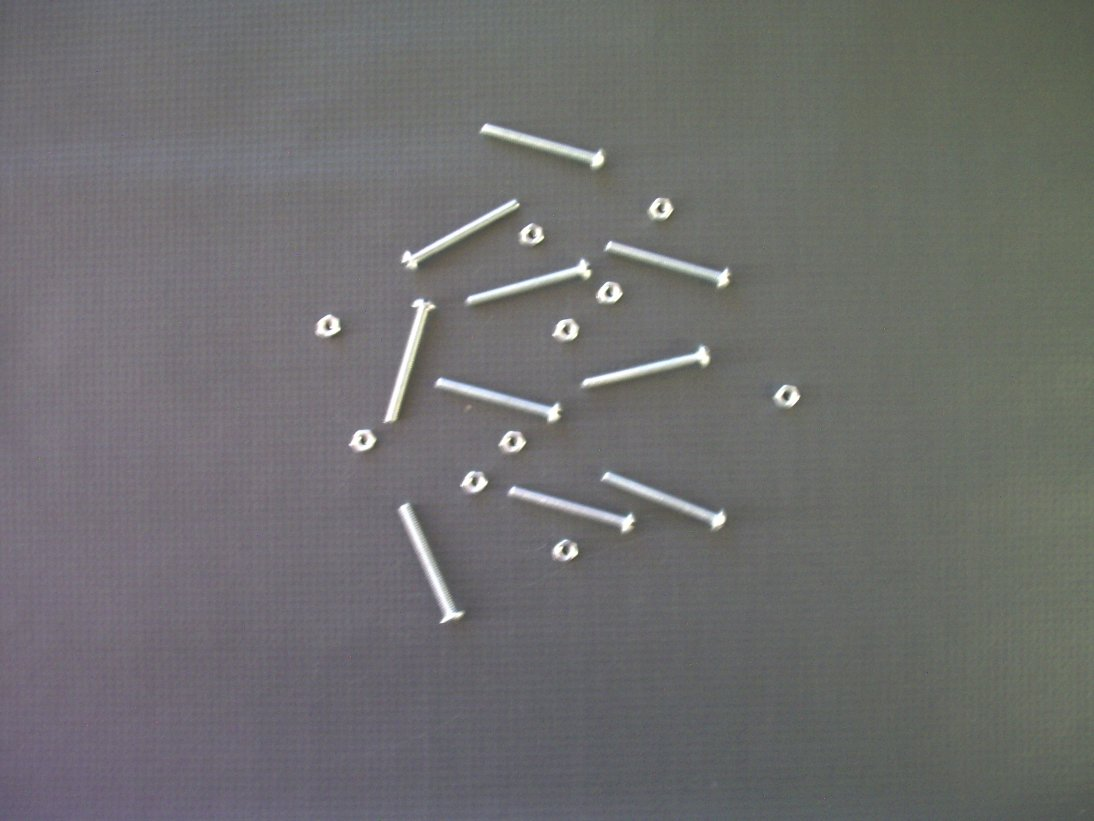

In [ ]:
# Etapa 2: Leitura da imagem de referência e conversão BGR → RGB
img_bgr = cv.imread(img_ref_path)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Exibe a imagem de referência
print("Imagem de Referência (img01.jpg):")
cv2_imshow(img_bgr)  # Imagem original em BGR


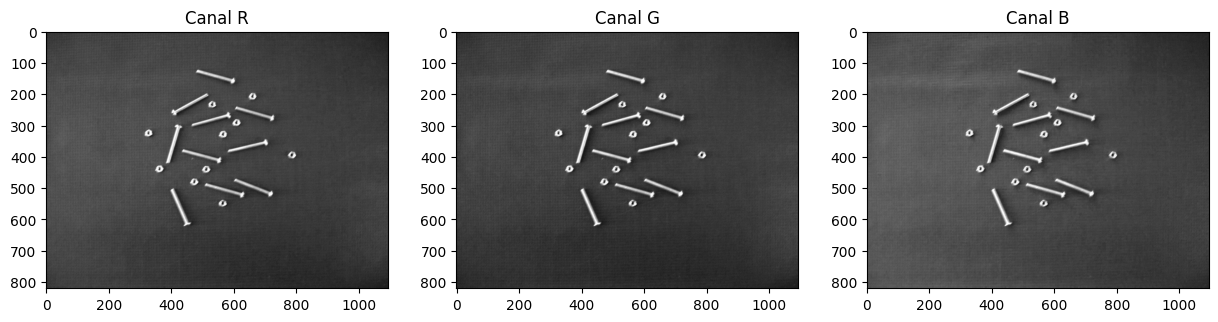

In [ ]:
# Etapa 3: Separação das bandas
R, G, B = cv.split(img_rgb)

# Exibe cada canal
plt.figure(figsize=(15,4))
plt.subplot(1, 3, 1)
plt.title('Canal R')
plt.imshow(R, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('Canal G')
plt.imshow(G, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Canal B')
plt.imshow(B, cmap='gray')
plt.show()


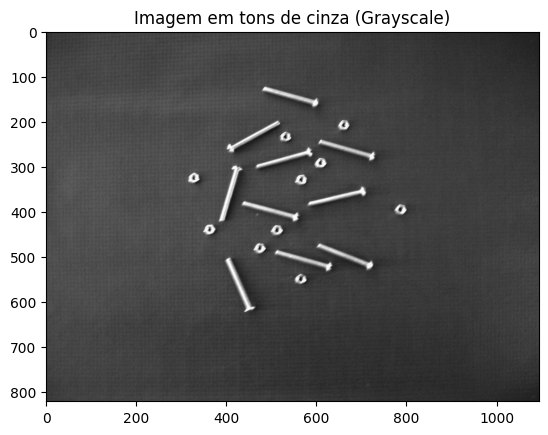

In [ ]:
# Etapa 4: Conversão RGB para Grayscale manual
img_gray = (R.astype(int) + G.astype(int) + B.astype(int)) // 3
img_gray = img_gray.astype(np.uint8)

# Exibe imagem em tons de cinza
plt.title("Imagem em tons de cinza (Grayscale)")
plt.imshow(img_gray, cmap='gray')
plt.show()


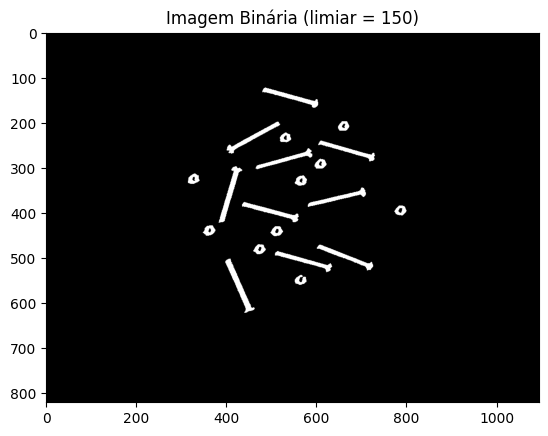

In [ ]:
# Etapa 5: Conversão de Grayscale para Binária com limiarização
thresh_val = 150
_, img_bin = cv.threshold(img_gray, thresh_val, 255, cv.THRESH_BINARY)

plt.title("Imagem Binária (limiar = 150)")
plt.imshow(img_bin, cmap='gray')
plt.show()


Objetos detectados na imagem de referência: 20
Stats da imagem de referência (cada linha é um objeto):
[[     0      0   1094    821 881147]
 [   480    123    124     45   1294]
 [   648    198     25     21    371]
 [   401    199    119     71   1286]
 [   519    223     25     22    359]
 [   604    241    126     46   1204]
 [   465    258    126     47   1169]
 [   596    281     27     22    386]
 [   383    298     53    125   1561]
 [   315    314     26     23    401]
 [   552    318     27     23    410]
 [   581    345    129     43   1222]
 [   435    377    126     45   1312]
 [   773    385     27     22    370]
 [   348    429     28     23    417]
 [   498    431     28     22    390]
 [   460    471     28     22    384]
 [   601    472    125     57   1276]
 [   508    486    127     47   1238]
 [   398    503     65    120   1628]
 [   552    539     26     22    349]]


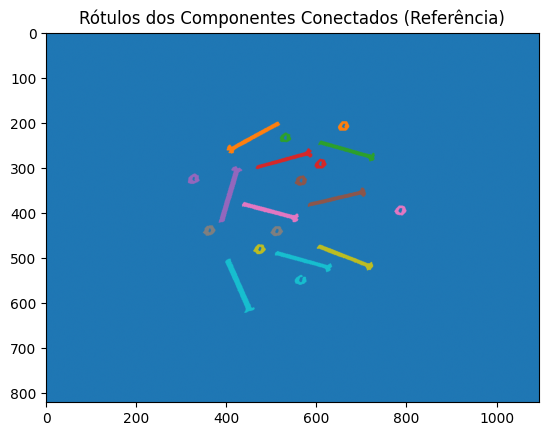

📏 Média de área - Porcas: 354.60, Parafusos: 1200.50


In [ ]:
# Etapa 6: Análise de Componentes Conectados (CCs) na imagem de referência
numCCs_ref, imgLabels_ref, stats_ref, centroids_ref = cv.connectedComponentsWithStats(img_bin, connectivity=4)

# Exibe resultado
print(f"Objetos detectados na imagem de referência: {numCCs_ref - 1}")
print("Stats da imagem de referência (cada linha é um objeto):")
print(stats_ref)

# Visualização dos rótulos
plt.title("Rótulos dos Componentes Conectados (Referência)")
plt.imshow(imgLabels_ref, cmap='tab10')
plt.show()

# Salva o número de objetos esperados
objetos_esperados = numCCs_ref - 1

# Leitura da imagem de referência (binária já processada)
img_ref = cv.imread(os.path.join(PATH, "img01.jpg"), 0)
_, img_ref_bin = cv.threshold(img_ref, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Análise de Componentes Conectados
numCCs_ref, labels_ref, stats_ref, centroids_ref = cv.connectedComponentsWithStats(img_ref_bin, connectivity=4)

# Extrai as áreas (ignora o fundo)
areas_ref = stats_ref[1:, cv.CC_STAT_AREA]

# Ordena por área (descartando ruídos pequenos e mantendo apenas os 20 maiores objetos)
indices_maiores = np.argsort(areas_ref)[-20:]
areas_filtradas = areas_ref[indices_maiores].reshape(-1, 1)

# K-Means para separar objetos em 2 grupos: porcas e parafusos
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42).fit(areas_filtradas)
labels_km = kmeans.labels_
centroids = kmeans.cluster_centers_.flatten()

# Determinar qual cluster é porca (menor área) e qual é parafuso (maior área)
if centroids[0] < centroids[1]:
    media_porcas = centroids[0]
    media_parafusos = centroids[1]
else:
    media_porcas = centroids[1]
    media_parafusos = centroids[0]

print(f"📏 Média de área - Porcas: {media_porcas:.2f}, Parafusos: {media_parafusos:.2f}")

# Aplicar erosão e dilatação para separar objetos grudados (opcional)
kernel = np.ones((3,3), np.uint8)
img_bin = cv.morphologyEx(img_bin, cv.MORPH_OPEN, kernel)


In [ ]:
# Função para classificar objetos com base na área mais próxima
def classificar_objetos_por_area(stats, media_porcas, media_parafusos):
    porcas = 0
    parafusos = 0

    for i in range(1, stats.shape[0]):
        area = stats[i, cv.CC_STAT_AREA]
        if abs(area - media_porcas) < abs(area - media_parafusos):
            porcas += 1
        else:
            parafusos += 1

    return porcas, parafusos



📦 Analisando: img02.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 12 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


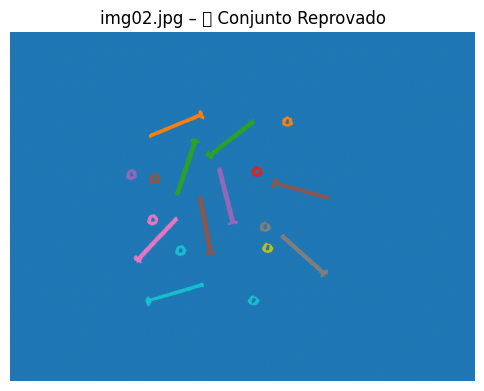


📦 Analisando: img03.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 14 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


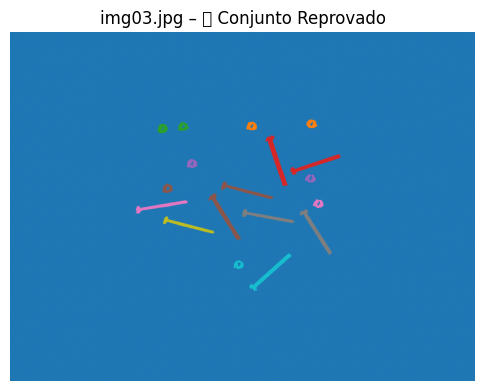


📦 Analisando: img04.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 11 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


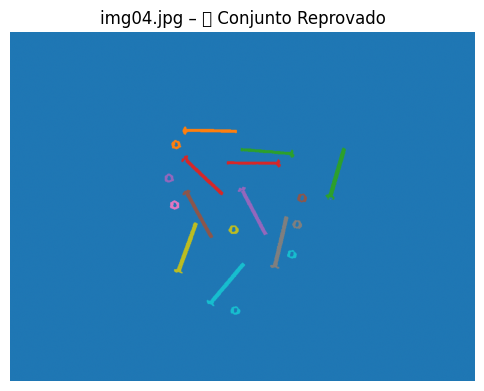


📦 Analisando: img05.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 311 (Quantidade Correta: 10)
🔩 Parafusos detectados: 9 (Quantidade Correta: 10)
⚠️ Faltam 1 parafuso(s)


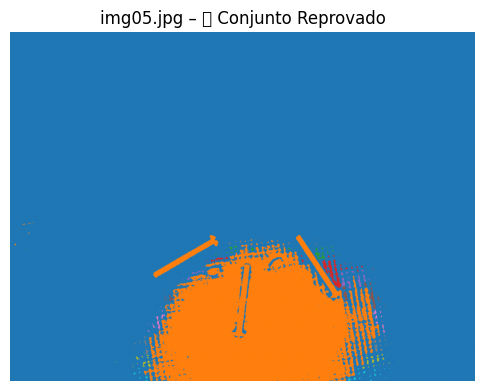


📦 Analisando: img06.jpg
✅ Conjunto Aprovado
🔘 Porcas detectadas: 10 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


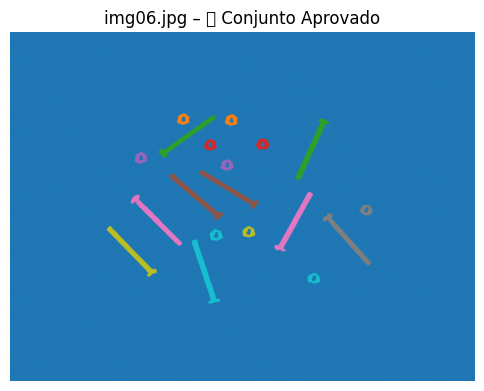


📦 Analisando: img07.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 9 (Quantidade Correta: 10)
🔩 Parafusos detectados: 8 (Quantidade Correta: 10)
⚠️ Faltam 1 porca(s)
⚠️ Faltam 2 parafuso(s)


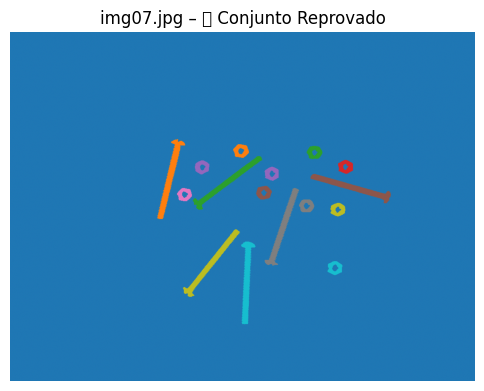


📦 Analisando: img08.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 760 (Quantidade Correta: 10)
🔩 Parafusos detectados: 4 (Quantidade Correta: 10)
⚠️ Faltam 6 parafuso(s)


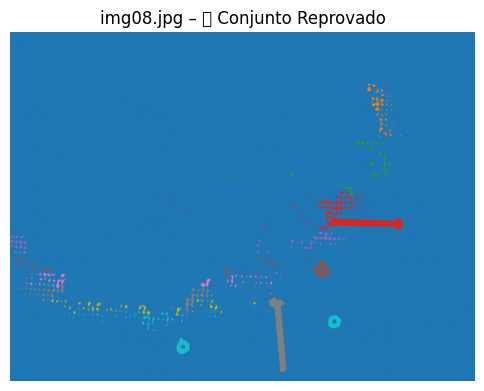


📦 Analisando: img09.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 15 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


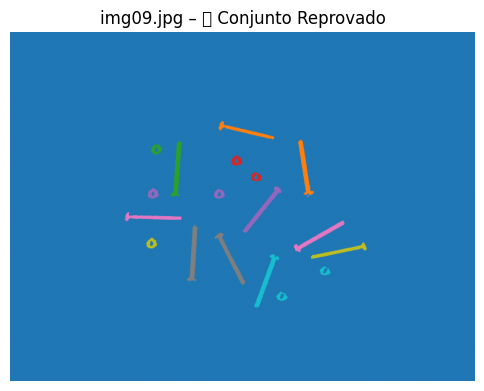


📦 Analisando: img10.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 12 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


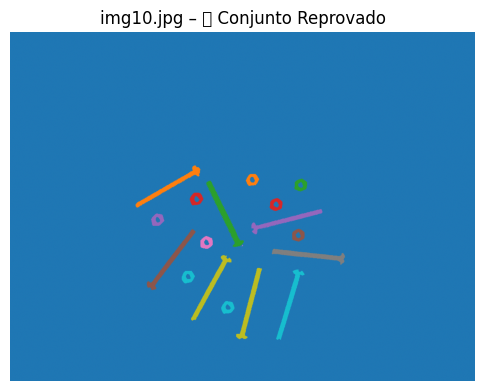


📦 Analisando: img11.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 804 (Quantidade Correta: 10)
🔩 Parafusos detectados: 7 (Quantidade Correta: 10)
⚠️ Faltam 3 parafuso(s)


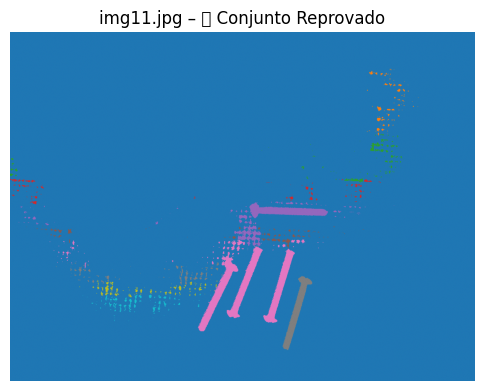


📦 Analisando: img12.jpg
✅ Conjunto Aprovado
🔘 Porcas detectadas: 10 (Quantidade Correta: 10)
🔩 Parafusos detectados: 10 (Quantidade Correta: 10)


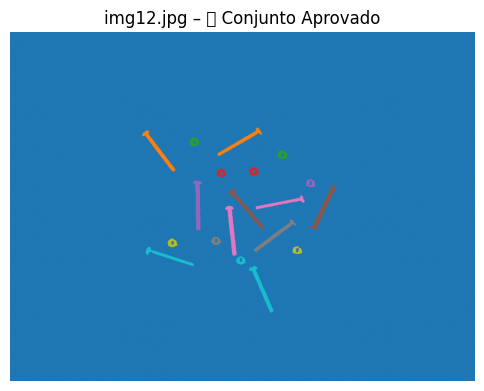


📦 Analisando: img13.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 777 (Quantidade Correta: 10)
🔩 Parafusos detectados: 3 (Quantidade Correta: 10)
⚠️ Faltam 7 parafuso(s)


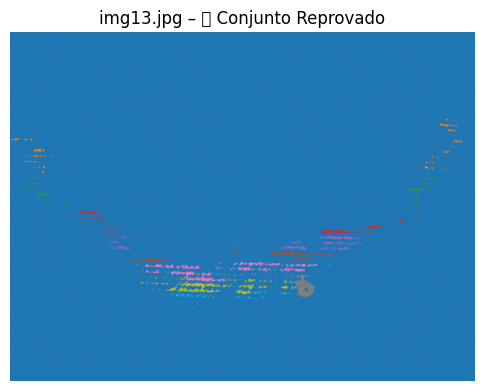


📦 Analisando: img14.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 671 (Quantidade Correta: 10)
🔩 Parafusos detectados: 7 (Quantidade Correta: 10)
⚠️ Faltam 3 parafuso(s)


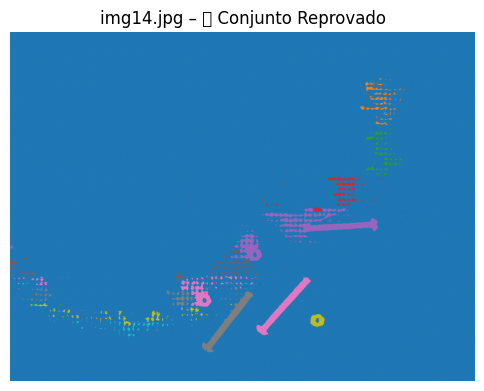


📦 Analisando: img15.jpg
❌ Conjunto Reprovado
🔘 Porcas detectadas: 695 (Quantidade Correta: 10)
🔩 Parafusos detectados: 5 (Quantidade Correta: 10)
⚠️ Faltam 5 parafuso(s)


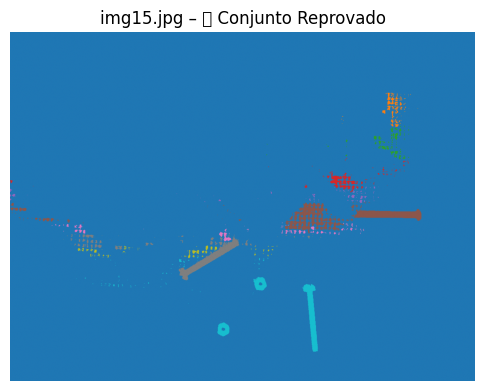

In [ ]:
# Lista das imagens a serem avaliadas (exceto referência)
image_files = sorted([f for f in os.listdir(PATH) if f.endswith(".jpg") and f != "img01.jpg"])

# Referência de quantidade
porcas_ref = 10
parafusos_ref = 10

for filename in image_files:
    print(f"\n📦 Analisando: {filename}")

    img = cv.imread(os.path.join(PATH, filename), 0)
    _, img_bin = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    numCCs, labels, stats, centroids = cv.connectedComponentsWithStats(img_bin, connectivity=4)

    # Classificação com base na média da referência
    porcas_detectadas, parafusos_detectados = classificar_objetos_por_area(stats, media_porcas, media_parafusos)

    # Avaliação
    falta_porcas = porcas_ref - porcas_detectadas
    falta_parafusos = parafusos_ref - parafusos_detectados

    if falta_porcas == 0 and falta_parafusos == 0:
        status = "✅ Conjunto Aprovado"
    else:
        status = "❌ Conjunto Reprovado"

    # Exibir resultados
    print(f"{status}")
    print(f"🔘 Porcas detectadas: {porcas_detectadas} (Quantidade Correta: {porcas_ref})")
    print(f"🔩 Parafusos detectados: {parafusos_detectados} (Quantidade Correta: {parafusos_ref})")

    if falta_porcas > 0:
        print(f"⚠️ Faltam {falta_porcas} porca(s)")
    if falta_parafusos > 0:
        print(f"⚠️ Faltam {falta_parafusos} parafuso(s)")

    # Visualização
    plt.figure(figsize=(6, 6))
    plt.title(f"{filename} – {status}")
    plt.imshow(labels, cmap='tab10')
    plt.axis('off')
    plt.show()
